# **Comparison of All Three Approaches**

To understand the overall effectiveness of each modelling strategy, we compare the results of the three approaches—**TF-IDF + SVM**, **Word2Vec + LSTM**, and **MentalBERT**—using consistent evaluation metrics. Since the dataset is highly imbalanced, we focus primarily on **macro F1** and **per-class performance**, which provide a fair assessment across all mental-health categories. This comparison highlights how each method handles nuanced emotional expressions, minority classes, and contextual understanding.


In [1]:
import pandas as pd

In [2]:
comparison_summary = pd.DataFrame([
    ["TF-IDF + SVM",   0.7664, 0.7118],
    ["Word2Vec + LSTM",0.6857, 0.7345],
    ["MentalBERT",     0.8423, 0.8380]
],
    columns=["Model", "Test Accuracy", "Macro F1"]
)

display(comparison_summary)

,Model,Test Accuracy,Macro F1
0,TF-IDF + SVM,0.7664,0.7118
1,Word2Vec + LSTM,0.6857,0.7345
2,MentalBERT,0.8423,0.8380


**Overall, the comparison highlights a clear performance gap across the three approaches.**  
While *TF-IDF + SVM* offers solid baseline results and *Word2Vec + LSTM* captures sequential patterns better, both models struggle with minority and nuanced categories due to limited contextual understanding. **MentalBERT** stands out with the *highest test accuracy* and *best macro F1 score*, demonstrating strong generalization across all classes—including low-frequency labels.  
**These results confirm that transformer-based models provide the most balanced, robust, and context-aware performance for mental-health text classification.**


In [3]:
# 1) TF-IDF + SVM
svm_f1 = {
    "Normal":               0.9115,
    "Depression":           0.7034,
    "Suicidal":             0.6836,
    "Anxiety":              0.7745,
    "Bipolar":              0.7555,
    "Stress":               0.5623,
    "Personality disorder": 0.5917
}

# 2) Word2Vec + LSTM 
lstm_f1 = {
    "Normal":               0.9272,
    "Depression":           0.6308,
    "Suicidal":             0.6916,
    "Anxiety":              0.7895,
    "Bipolar":              0.8016,
    "Stress":               0.5854,
    "Personality disorder": 0.5269
}

#3) Transformer (MentalBERT)
mentalbert_f1 = {
    "Normal":               0.9559,
    "Depression":           0.7848,
    "Suicidal":             0.7515,
    "Anxiety":              0.8715,
    "Bipolar":              0.8870,
    "Stress":               0.7850,
    "Personality disorder": 0.8300
}

In [4]:
LABEL_ORDER = ["Normal", "Depression", "Suicidal", "Anxiety", "Bipolar", "Stress", "Personality disorder"]

In [5]:
comparison_df = pd.DataFrame({
    "Class": LABEL_ORDER,
    "TF-IDF + SVM":       [svm_f1[c] for c in LABEL_ORDER],
    "Word2Vec + LSTM":    [lstm_f1[c] for c in LABEL_ORDER],
    "MentalBERT":         [mentalbert_f1[c] for c in LABEL_ORDER],
})

aligned_df = comparison_df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}]
)
aligned_df

,Class,TF-IDF + SVM,Word2Vec + LSTM,MentalBERT
0,Normal,0.911500,0.927200,0.955900
1,Depression,0.703400,0.630800,0.784800
2,Suicidal,0.683600,0.691600,0.751500
3,Anxiety,0.774500,0.789500,0.871500
4,Bipolar,0.755500,0.801600,0.887000
5,Stress,0.562300,0.585400,0.785000
6,Personality disorder,0.591700,0.526900,0.830000


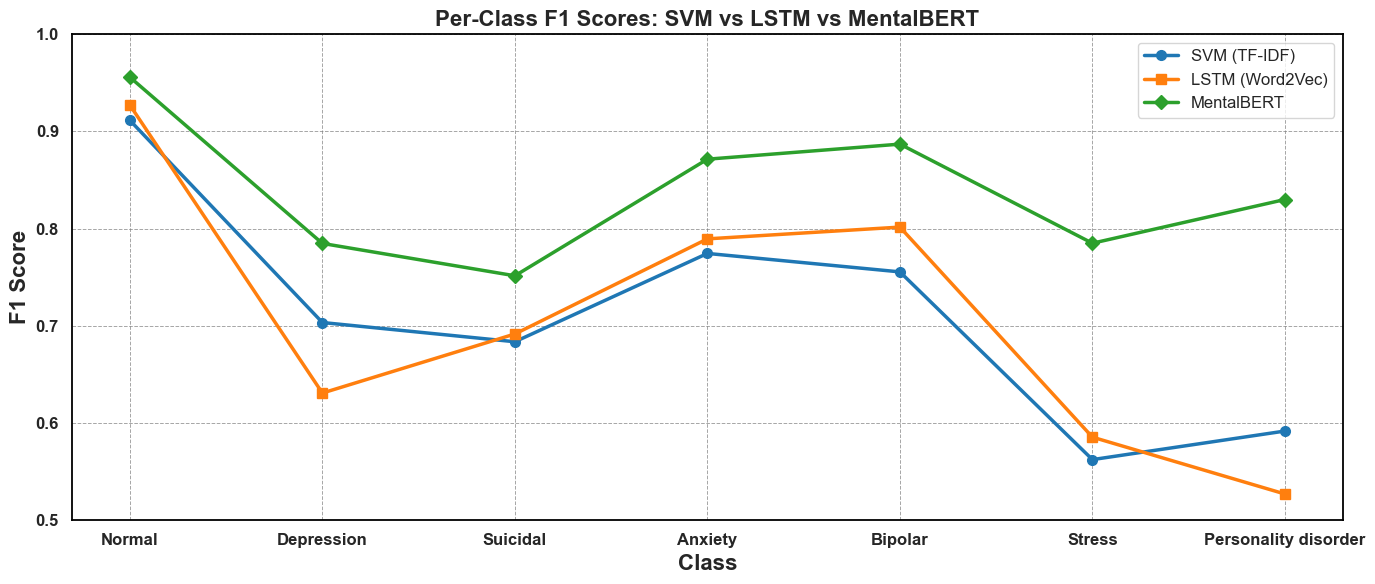

In [15]:
# Improved Per-Class F1 Plot: SVM vs LSTM vs MentalBERT

import matplotlib.pyplot as plt
import seaborn as sns

classes = LABEL_ORDER

svm_vals = [svm_f1[c] for c in classes]
lstm_vals = [lstm_f1[c] for c in classes]
bert_vals = [mentalbert_f1[c] for c in classes]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

# Use nicer colors + thicker smoother lines
plt.plot(classes, svm_vals, marker="o", linewidth=2.5, markersize=7,
         label="SVM (TF-IDF)", color="#1f77b4")

plt.plot(classes, lstm_vals, marker="s", linewidth=2.5, markersize=7,
         label="LSTM (Word2Vec)", color="#ff7f0e")

plt.plot(classes, bert_vals, marker="D", linewidth=2.5, markersize=7,
         label="MentalBERT", color="#2ca02c")

# Title and labels
plt.title("Per-Class F1 Scores: SVM vs LSTM vs MentalBERT",
          fontsize=16, fontweight="bold")
plt.xlabel("Class", fontsize=16, fontweight="bold")
plt.ylabel("F1 Score", fontsize=16, fontweight="bold")

# Tighter y-axis for better clarity
plt.ylim(0.5, 1.0)

# Better grid
plt.grid(
    True, 
    which="major", 
    linestyle="--", 
    linewidth=0.7, 
    alpha=0.7,
    color="grey"
)

# Improve tick font sizes
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

for spine in plt.gca().spines.values():
    spine.set_linewidth(1.3)
    spine.set_color("black")
    
# Legend
plt.legend(fontsize=12, frameon=True, shadow=False, facecolor="white")

plt.tight_layout()
plt.show()


### Comparison of All Three Models

The comparative evaluation across *TF-IDF + SVM*, *Word2Vec + LSTM*, and *MentalBERT* clearly shows a consistent performance hierarchy. Traditional approaches capture broad textual patterns but struggle with nuanced emotional cues and minority classes. The LSTM model benefits from distributed word embeddings and learns sequential dependencies, offering improved balance over the classical method. However, the domain-adapted transformer model, **MentalBERT**, stands out as the most effective approach. Its ability to leverage deep contextual representations enables significantly higher macro F1 scores and superior per-class performance, even for infrequent categories. Overall, **MentalBERT provides the most reliable, accurate, and generalizable results**, making it the best-suited model for mental-health text classification in this study.